In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

In [2]:
bank_loan_approval_dataset = pd.read_csv(
    csv_path if "csv_path" in globals() else "feed/bank_loan_approval_dataset_2a.csv"
)

bank_loan_approval_dataset.head()

,application_id,first_name,last_name,age,employment_type,employment_years,annual_income,credit_score,debt_to_income_ratio,savings_balance,existing_loans_count,missed_payments_12m,home_ownership,loan_purpose,loan_term_months,interest_rate,requested_loan_amount,loan_approved,loan_approved decision,approved_loan_amount
0,APP00002,Aiden0002,Baker0002,55,Salaried,27,90949.60,643,0.313,9760.72,3,0,Rent,Business,48,14.35,24216.29,1,Yes,16041.35
1,APP00003,Amara0003,Brooks0003,50,Salaried,24,60941.84,748,0.476,53373.76,2,0,Mortgage,Personal,72,13.05,29579.03,1,Yes,19484.45
2,APP00005,Caleb0005,Coleman0005,40,Business Owner,18,57200.50,654,0.465,32561.08,2,0,Rent,Medical,12,14.00,27119.93,1,Yes,15375.22
3,APP00010,Eva0010,Foster0010,25,Business Owner,0,98637.37,519,0.569,64155.87,4,0,Rent,Home Improvement,12,18.31,19481.81,1,Yes,6891.17
4,APP00012,Henry0012,Gomez0012,64,Self-Employed,36,31714.23,814,0.416,18727.89,2,0,Rent,Medical,36,11.02,9329.50,1,Yes,7244.91


In [3]:
bank_loan_approval_dataset.approved_loan_amount.value_counts(dropna=False)

approved_loan_amount
29747.24    1
16041.35    1
19484.45    1
15375.22    1
6891.17     1
           ..
16955.35    1
52615.08    1
42571.71    1
50253.81    1
22831.24    1
Name: count, Length: 441, dtype: int64

In [4]:
bank_loan_approval_dataset.approved_loan_amount.value_counts(dropna=False)

approved_loan_amount
29747.24    1
16041.35    1
19484.45    1
15375.22    1
6891.17     1
           ..
16955.35    1
52615.08    1
42571.71    1
50253.81    1
22831.24    1
Name: count, Length: 441, dtype: int64

In [5]:
# Count how many values in approved_loan_amount are 0

if "bank_loan_approval_dataset2" in globals():
    approved_loan_amount = bank_loan_approval_dataset2["approved_loan_amount"]
elif "bank_loan_approval_dataset" in globals():
    approved_loan_amount = bank_loan_approval_dataset["approved_loan_amount"]
elif "target" in globals():
    approved_loan_amount = target["approved_loan_amount"] if "approved_loan_amount" in target else target.squeeze()
elif "y_vals" in globals():
    approved_loan_amount = pd.Series(y_vals, name="approved_loan_amount")
else:
    raise NameError("No approved_loan_amount source found in the notebook.")

zero_count = np.isclose(approved_loan_amount, 0).sum()
total_count = len(approved_loan_amount)
zero_pct = (zero_count / total_count) * 100

print(f"approved_loan_amount == 0 count: {zero_count}")
print(f"total rows: {total_count}")
print(f"zero percentage: {zero_pct:.2f}%")

approved_loan_amount == 0 count: 0
total rows: 441
zero percentage: 0.00%


In [6]:
bank_loan_approval_dataset2 =  bank_loan_approval_dataset.copy()
bank_loan_approval_dataset2.shape,bank_loan_approval_dataset.shape



((441, 20), (441, 20))

#### Creating dataframes with numeric and non numeric columns 

In [7]:
numeric_cols2 = bank_loan_approval_dataset2[[
    "employment_years",
    "annual_income",
    "credit_score",
    "debt_to_income_ratio",
    "savings_balance",
    "existing_loans_count",
    "missed_payments_12m",
    "age",
    "approved_loan_amount",
]]

In [8]:
non_numeric_cols = bank_loan_approval_dataset2[[
    "employment_years",
    "annual_income",
    "credit_score",
    "debt_to_income_ratio",
    "savings_balance",
    "existing_loans_count",
    "missed_payments_12m",
    "age",
    "home_ownership",
    "loan_purpose",
    "approved_loan_amount",
]]

In [9]:
# non_numeric_cols.head()

In [10]:
numeric_cols2.head()

,employment_years,annual_income,credit_score,debt_to_income_ratio,savings_balance,existing_loans_count,missed_payments_12m,age,approved_loan_amount
0,27,90949.60,643,0.313,9760.72,3,0,55,16041.35
1,24,60941.84,748,0.476,53373.76,2,0,50,19484.45
2,18,57200.50,654,0.465,32561.08,2,0,40,15375.22
3,0,98637.37,519,0.569,64155.87,4,0,25,6891.17
4,36,31714.23,814,0.416,18727.89,2,0,64,7244.91


In [11]:
# Remove rows where approved_loan_amount is 0, and overwrite numeric_cols, so the model can improve ansd avoid overfitting
numeric_cols = numeric_cols2.loc[~np.isclose(numeric_cols2["approved_loan_amount"], 0)].copy()

print("Updated numeric_cols shape:", numeric_cols.shape)
print("Remaining zero values:", np.isclose(numeric_cols["approved_loan_amount"], 0).sum())
numeric_cols.head()

Updated numeric_cols shape: (441, 9)
Remaining zero values: 0


,employment_years,annual_income,credit_score,debt_to_income_ratio,savings_balance,existing_loans_count,missed_payments_12m,age,approved_loan_amount
0,27,90949.60,643,0.313,9760.72,3,0,55,16041.35
1,24,60941.84,748,0.476,53373.76,2,0,50,19484.45
2,18,57200.50,654,0.465,32561.08,2,0,40,15375.22
3,0,98637.37,519,0.569,64155.87,4,0,25,6891.17
4,36,31714.23,814,0.416,18727.89,2,0,64,7244.91


In [12]:
numeric_cols.approved_loan_amount.value_counts(dropna=False)

approved_loan_amount
29747.24    1
16041.35    1
19484.45    1
15375.22    1
6891.17     1
           ..
16955.35    1
52615.08    1
42571.71    1
50253.81    1
22831.24    1
Name: count, Length: 441, dtype: int64

In [13]:
target2 = bank_loan_approval_dataset2[[
    "approved_loan_amount"
]]

In [14]:
target2.head()

,approved_loan_amount
0,16041.35
1,19484.45
2,15375.22
3,6891.17
4,7244.91


In [15]:
# Remove rows where approved_loan_amount is 0.00 and create dataframe: target
if "target2" not in globals():
    raise NameError("target2 is not defined. Run the cell that creates target2 first.")

target = target2.loc[~np.isclose(target2["approved_loan_amount"], 0)].copy()

print("target shape:", target.shape)
print("Remaining zero values:", np.isclose(target["approved_loan_amount"], 0).sum())
target.head()

target shape: (441, 1)
Remaining zero values: 0


,approved_loan_amount
0,16041.35
1,19484.45
2,15375.22
3,6891.17
4,7244.91


In [16]:
target.approved_loan_amount.value_counts(dropna=False)

approved_loan_amount
29747.24    1
16041.35    1
19484.45    1
15375.22    1
6891.17     1
           ..
16955.35    1
52615.08    1
42571.71    1
50253.81    1
22831.24    1
Name: count, Length: 441, dtype: int64

In [17]:
numeric_cols.head()

,employment_years,annual_income,credit_score,debt_to_income_ratio,savings_balance,existing_loans_count,missed_payments_12m,age,approved_loan_amount
0,27,90949.60,643,0.313,9760.72,3,0,55,16041.35
1,24,60941.84,748,0.476,53373.76,2,0,50,19484.45
2,18,57200.50,654,0.465,32561.08,2,0,40,15375.22
3,0,98637.37,519,0.569,64155.87,4,0,25,6891.17
4,36,31714.23,814,0.416,18727.89,2,0,64,7244.91


In [18]:
# numeric_cols.approved_loan_amount.value_counts(dropna=False)

#### Creating a best fit line for the non numeric dataframe

In [19]:
approved_loan_amount

0      16041.35
1      19484.45
2      15375.22
3       6891.17
4       7244.91
         ...   
436    41777.21
437    11681.14
438    13210.67
439     9300.43
440    29747.24
Name: approved_loan_amount, Length: 441, dtype: float64

In [20]:
import matplotlib.pyplot as plt

Samples used: X=441, y=441
Best-fit equation:
approved_loan_amount = (0.381424) * annual_income + (-4664.531908)


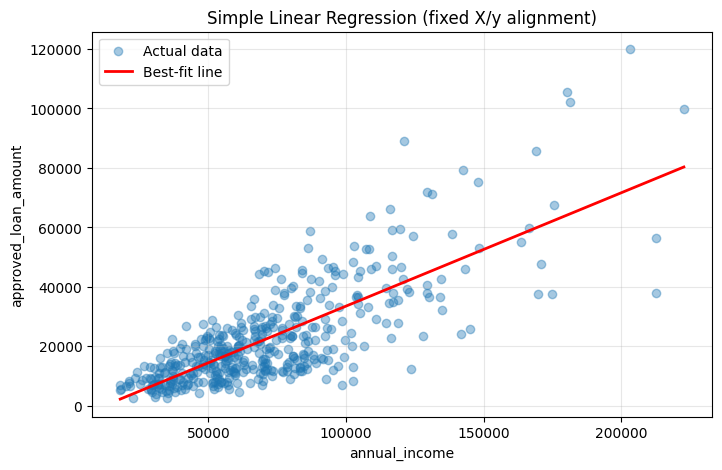

In [21]:
# Fixed simple linear regression cell (ensures X and y come from the same rows)

feature = "annual_income"
target_col = "approved_loan_amount"

# Pick the best available dataframe
if "numeric_cols" in globals():
    source_df = numeric_cols.copy()  # already filtered (non-zero target) in your notebook
elif "bank_loan_approval_dataset2" in globals():
    source_df = bank_loan_approval_dataset2.copy()
elif "bank_loan_approval_dataset" in globals():
    source_df = bank_loan_approval_dataset.copy()
else:
    raise NameError("No source dataframe found.")

# Build aligned X and y from the same dataframe (fixes inconsistent sample sizes)
model_df = source_df[[feature, target_col]].dropna().copy()
x_simple = model_df[[feature]]
y_simple = model_df[target_col]

# Fit model
simple_model = LinearRegression()
simple_model.fit(x_simple, y_simple)

m = float(np.ravel(simple_model.coef_)[0])
b = float(np.ravel([simple_model.intercept_])[0])

print(f"Samples used: X={len(x_simple)}, y={len(y_simple)}")
print(f"Best-fit equation:\napproved_loan_amount = ({m:.6f}) * {feature} + ({b:.6f})")

# Plot
x_vals = x_simple[feature].values
y_pred_simple = simple_model.predict(x_simple)

order = np.argsort(x_vals)
plt.figure(figsize=(8, 5))
plt.scatter(x_vals, y_simple.values, alpha=0.4, label="Actual data")
plt.plot(x_vals[order], y_pred_simple[order], color="red", linewidth=2, label="Best-fit line")
plt.xlabel(feature)
plt.ylabel(target_col)
plt.title("Simple Linear Regression (fixed X/y alignment)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Implementing y=mx+ b for the numeric dataframe

In [22]:
# Best-fit line equation explanation
print("=" * 60)
print("Simple Linear Regression: Best-Fit Line Equation")
print("=" * 60)
print()
print("Formula:  y = m*x + b")
print()
print("Where:")
print(f"  y  = approved_loan_amount (target / dependent variable)")
print(f"  x  = annual_income         (feature / independent variable)")
print(f"  m  = {m:.6f}             (slope)")
print(f"  b  = {b:.6f}          (intercept)")
print()
print("So the equation is:")
print(f"  approved_loan_amount = ({m:.6f}) * annual_income + ({b:.6f})")
print()
print("How m and b were calculated:")
print("-" * 60)
print("  m (slope)     = Σ[(xᵢ - x̄)(yᵢ - ȳ)] / Σ[(xᵢ - x̄)²]")
print("  b (intercept) = ȳ - m * x̄")
print()

x_mean = x_simple["annual_income"].mean()
y_mean = y_simple.mean()

print(f"  x̄ (mean of annual_income)           = {x_mean:,.2f}")
print(f"  ȳ (mean of approved_loan_amount)   = {y_mean:,.2f}")
print()
print(f"  b = ȳ - m * x̄")
print(f"  b = {y_mean:.2f} - ({m:.6f} * {x_mean:.2f})")
print(f"  b = {b:.6f}")
print()
print("Interpretation:")
print(f"  For every $1 increase in annual_income,")
print(f"  the approved_loan_amount increases by ${m:.6f}")
print(f"  When annual_income = 0, predicted approved_loan_amount = ${b:.2f}")

Simple Linear Regression: Best-Fit Line Equation

Formula:  y = m*x + b

Where:
  y  = approved_loan_amount (target / dependent variable)
  x  = annual_income         (feature / independent variable)
  m  = 0.381424             (slope)
  b  = -4664.531908          (intercept)

So the equation is:
  approved_loan_amount = (0.381424) * annual_income + (-4664.531908)

How m and b were calculated:
------------------------------------------------------------
  m (slope)     = Σ[(xᵢ - x̄)(yᵢ - ȳ)] / Σ[(xᵢ - x̄)²]
  b (intercept) = ȳ - m * x̄

  x̄ (mean of annual_income)           = 71,265.73
  ȳ (mean of approved_loan_amount)   = 22,517.92

  b = ȳ - m * x̄
  b = 22517.92 - (0.381424 * 71265.73)
  b = -4664.531908

Interpretation:
  For every $1 increase in annual_income,
  the approved_loan_amount increases by $0.381424
  When annual_income = 0, predicted approved_loan_amount = $-4664.53


#### Implementing y = mx + b for the numeric dataframe (Using Multiple features)

In [23]:
target.approved_loan_amount.value_counts(dropna=False)

approved_loan_amount
29747.24    1
16041.35    1
19484.45    1
15375.22    1
6891.17     1
           ..
16955.35    1
52615.08    1
42571.71    1
50253.81    1
22831.24    1
Name: count, Length: 441, dtype: int64

In [24]:
approved_loan_amount

0      16041.35
1      19484.45
2      15375.22
3       6891.17
4       7244.91
         ...   
436    41777.21
437    11681.14
438    13210.67
439     9300.43
440    29747.24
Name: approved_loan_amount, Length: 441, dtype: float64

In [25]:
# Multiple Linear Regression with constraint:
# force savings_balance (or savings_bank) coefficient to be non-negative

target_col = "approved_loan_amount"

# Build aligned X and y
if "numeric_cols" in globals():
    X_multi = numeric_cols.drop(columns=[target_col]).copy()

    if "target" in globals() and target_col in target.columns:
        y_candidate = target[target_col].copy()
        common_idx = X_multi.index.intersection(y_candidate.index)
        X_multi = X_multi.loc[common_idx]
        y_multi = y_candidate.loc[common_idx]
    else:
        y_multi = numeric_cols.loc[X_multi.index, target_col].copy()
else:
    raise NameError("numeric_cols not found. Run the data prep cells first.")

# Drop NaNs jointly
model_df = pd.concat([X_multi, y_multi.rename(target_col)], axis=1).dropna()
X_multi = model_df.drop(columns=[target_col])
y_multi = model_df[target_col]

# Detect savings column name
if "savings_balance" in X_multi.columns:
    savings_col = "savings_balance"
elif "savings_bank" in X_multi.columns:
    savings_col = "savings_bank"
else:
    raise KeyError("Neither 'savings_balance' nor 'savings_bank' exists in X_multi.")

# ---- Constrained fit (projected gradient descent) ----
X = X_multi.values.astype(float)
y = y_multi.values.astype(float)

x_mean = X.mean(axis=0)
x_std = X.std(axis=0)
x_std[x_std == 0] = 1.0
Xn = (X - x_mean) / x_std

n, p = Xn.shape
s_idx = X_multi.columns.get_loc(savings_col)

w = np.zeros(p, dtype=float)
b = 0.0
lr = 0.03
epochs = 8000

for _ in range(epochs):
    y_pred = Xn @ w + b
    err = y_pred - y

    grad_w = (Xn.T @ err) / n
    grad_b = err.mean()

    w -= lr * grad_w
    b -= lr * grad_b

    # enforce non-negative coefficient for savings feature
    w[s_idx] = max(0.0, w[s_idx])

# Convert back to original feature scale
coefs = w / x_std
intercept = b - np.sum(w * x_mean / x_std)

# Keep sklearn model variable for later notebook cells
multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)
multi_model.coef_ = coefs
multi_model.intercept_ = float(intercept)

# Stats/explanation
x_means = X_multi.mean()
y_mean = y_multi.mean()
b_from_means = float(y_mean - np.dot(coefs, x_means.values))
r2 = multi_model.score(X_multi, y_multi)

print("=" * 60)
print("Multiple Linear Regression (constrained savings coefficient)")
print("=" * 60)
print(f"Constraint applied: coef({savings_col}) >= 0")
print(f"R² (train): {r2:.4f}")
print()

print("Formula:  y = b + m1*x1 + m2*x2 + ... + mn*xn")
print()
print("Where:")
print("  y  = approved_loan_amount (target / dependent variable)")
for i, feat in enumerate(X_multi.columns, start=1):
    print(f"  x{i} = {feat}")
print()

for i, (feat, m_i) in enumerate(zip(X_multi.columns, coefs), start=1):
    print(f"  m{i} (coef for {feat}) = {m_i:+.6f}")
print(f"  b  (intercept)         = {intercept:+.6f}")
print()

terms = " ".join([f"({m_i:+.6f})*{feat}" for feat, m_i in zip(X_multi.columns, coefs)])
print("So the equation is:")
print(f"  approved_loan_amount = ({intercept:+.6f}) {terms}")
print()

print("How m and b were calculated:")
print("-" * 60)
print("  Minimize MSE with constraint: coef(savings) >= 0")
print("  b (intercept)               = ȳ - Σ(mj * x̄j)")
print()
print(f"  ȳ (mean of approved_loan_amount) = {y_mean:,.2f}")
for feat in X_multi.columns:
    print(f"  x̄ ({feat}) = {x_means[feat]:,.2f}")
print()
print("  b = ȳ - Σ(mj * x̄j)")
print(f"  b (from means) = {b_from_means:+.6f}")
print(f"  b (model)      = {intercept:+.6f}")
print()

print("Interpretation:")
for feat, m_i in zip(X_multi.columns, coefs):
    direction = "increases" if m_i >= 0 else "decreases"
    print(
        f"  Holding other features constant, +1 unit in {feat} {direction} "
        f"approved_loan_amount by {abs(m_i):.6f}."
    )

print(f"  When all features are 0, predicted approved_loan_amount = {intercept:,.2f}")

Multiple Linear Regression (constrained savings coefficient)
Constraint applied: coef(savings_balance) >= 0
R² (train): 0.6987

Formula:  y = b + m1*x1 + m2*x2 + ... + mn*xn

Where:
  y  = approved_loan_amount (target / dependent variable)
  x1 = employment_years
  x2 = annual_income
  x3 = credit_score
  x4 = debt_to_income_ratio
  x5 = savings_balance
  x6 = existing_loans_count
  x7 = missed_payments_12m
  x8 = age

  m1 (coef for employment_years) = +309.502909
  m2 (coef for annual_income) = +0.398612
  m3 (coef for credit_score) = +48.019120
  m4 (coef for debt_to_income_ratio) = -26759.361421
  m5 (coef for savings_balance) = +0.000000
  m6 (coef for existing_loans_count) = +474.016193
  m7 (coef for missed_payments_12m) = -1293.452021
  m8 (coef for age) = -287.275122
  b  (intercept)         = -26028.913544

So the equation is:
  approved_loan_amount = (-26028.913544) (+309.502909)*employment_years (+0.398612)*annual_income (+48.019120)*credit_score (-26759.361421)*debt_to_inc

#### Explaining Gradient Decent based on the cost function, (minimal cost function)

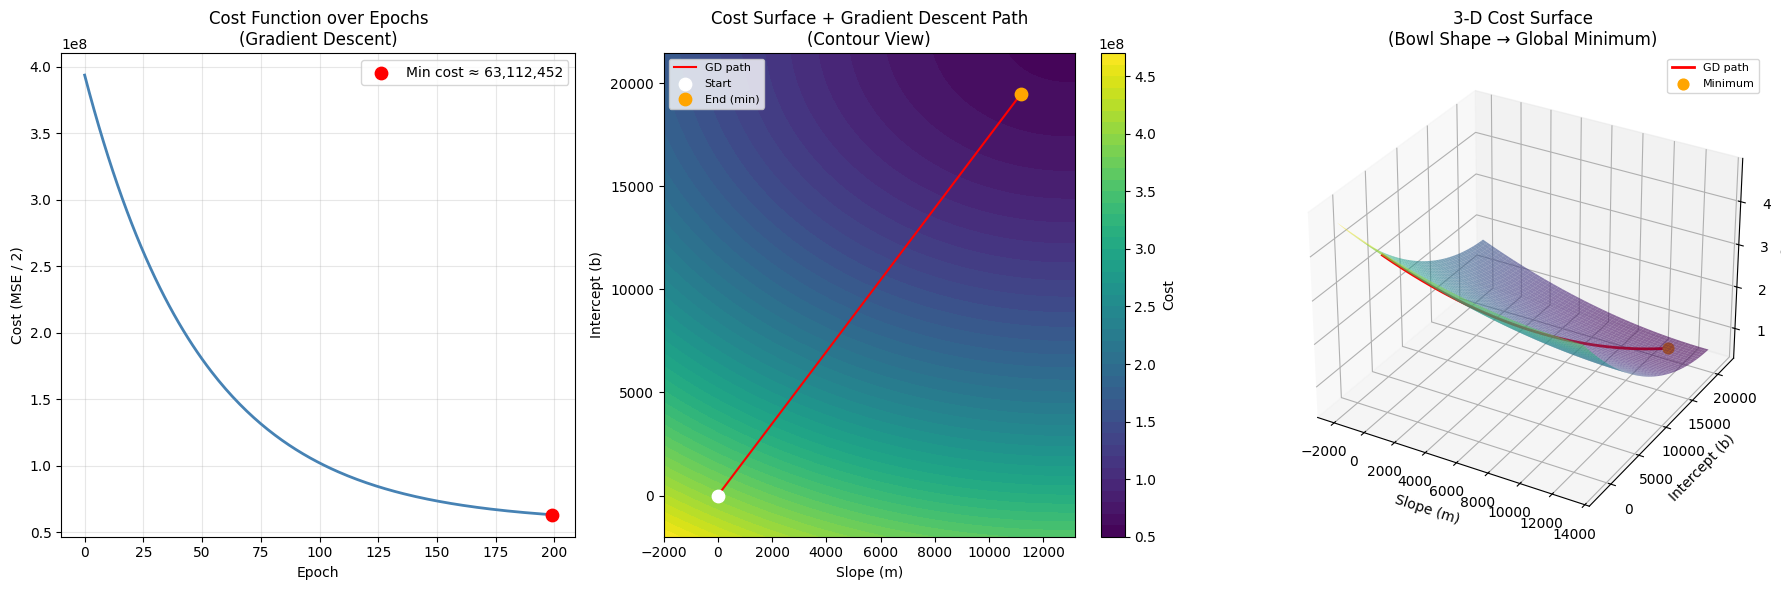

Gradient Descent Summary
  Learning rate      : 0.01
  Epochs             : 200
  Final slope  (m)   : 11,183.1603
  Final intercept (b): 19,500.9730
  Final cost (MSE/2) : 63,112,452.3872
  Min cost reached @ epoch 199

Update rules used:
  m  ←  m  -  α · (1/n) · Σ[(ŷᵢ - yᵢ) · xᵢ]
  b  ←  b  -  α · (1/n) · Σ[(ŷᵢ - yᵢ)    ]


In [26]:
# Gradient Descent Visualization - Cost Function Minimization
# Using simple linear regression (annual_income -> approved_loan_amount)

# ── Setup ──
x = x_simple["annual_income"].values
y_vals = y_simple.values

x_norm = (x - x.mean()) / x.std()   # normalize for stable gradient descent

# ── Gradient Descent ──
np.random.seed(42)
m_gd = 0.0          # slope
b_gd = 0.0          # intercept
lr    = 0.01        # learning rate
n     = len(x_norm)
epochs = 200

cost_history = []
m_history    = []
b_history    = []

for epoch in range(epochs):
    y_pred_gd = m_gd * x_norm + b_gd
    residuals = y_pred_gd - y_vals

    # Cost = MSE
    cost = (1 / (2 * n)) * np.sum(residuals ** 2)
    cost_history.append(cost)
    m_history.append(m_gd)
    b_history.append(b_gd)

    # Gradients
    dm = (1 / n) * np.sum(residuals * x_norm)
    db = (1 / n) * np.sum(residuals)

    # Update parameters
    m_gd -= lr * dm
    b_gd -= lr * db

# ── Grid for cost surface ──
m_range = np.linspace(min(m_history) - 2000, max(m_history) + 2000, 200)
b_range = np.linspace(min(b_history) - 2000, max(b_history) + 2000, 200)
M, B = np.meshgrid(m_range, b_range)

# Compute MSE over grid
Z = np.array([
    (1 / (2 * n)) * np.sum((mi * x_norm + bi - y_vals) ** 2)
    for mi, bi in zip(M.ravel(), B.ravel())
]).reshape(M.shape)

# ── Plot ──
fig = plt.figure(figsize=(18, 6))

# ---------- Plot 1: Cost vs Epoch ----------
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(range(epochs), cost_history, color="steelblue", linewidth=2)
ax1.scatter([np.argmin(cost_history)], [min(cost_history)],
            color="red", zorder=5, s=80, label=f"Min cost ≈ {min(cost_history):,.0f}")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cost (MSE / 2)")
ax1.set_title("Cost Function over Epochs\n(Gradient Descent)")
ax1.legend()
ax1.grid(alpha=0.3)

# ---------- Plot 2: Cost Surface (contour) + path ----------
ax2 = fig.add_subplot(1, 3, 2)
cp = ax2.contourf(M, B, Z, levels=50, cmap="viridis")
fig.colorbar(cp, ax=ax2, label="Cost")
ax2.plot(m_history, b_history, color="red", linewidth=1.5, label="GD path")
ax2.scatter(m_history[0],  b_history[0],  color="white",  s=80, zorder=5, label="Start")
ax2.scatter(m_history[-1], b_history[-1], color="orange", s=80, zorder=5, label="End (min)")
ax2.set_xlabel("Slope (m)")
ax2.set_ylabel("Intercept (b)")
ax2.set_title("Cost Surface + Gradient Descent Path\n(Contour View)")
ax2.legend(fontsize=8)

# ---------- Plot 3: 3-D cost surface ----------
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
ax3.plot_surface(M, B, Z, cmap="viridis", alpha=0.6, linewidth=0)
ax3.plot(m_history, b_history, cost_history, color="red", linewidth=2, label="GD path")
ax3.scatter([m_history[-1]], [b_history[-1]], [min(cost_history)],
            color="orange", s=60, zorder=5, label="Minimum")
ax3.set_xlabel("Slope (m)")
ax3.set_ylabel("Intercept (b)")
ax3.set_zlabel("Cost")
ax3.set_title("3-D Cost Surface\n(Bowl Shape → Global Minimum)")
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("=" * 55)
print("Gradient Descent Summary")
print("=" * 55)
print(f"  Learning rate      : {lr}")
print(f"  Epochs             : {epochs}")
print(f"  Final slope  (m)   : {m_gd:,.4f}")
print(f"  Final intercept (b): {b_gd:,.4f}")
print(f"  Final cost (MSE/2) : {cost_history[-1]:,.4f}")
print(f"  Min cost reached @ epoch {np.argmin(cost_history)}")
print()
print("Update rules used:")
print("  m  ←  m  -  α · (1/n) · Σ[(ŷᵢ - yᵢ) · xᵢ]")
print("  b  ←  b  -  α · (1/n) · Σ[(ŷᵢ - yᵢ)    ]")

#### Training the model based on the minumal cost function dereived from gradient decent

Multiple Linear Regression trained with Gradient Descent
Samples: 441 | Features: 8

Formula: y = b + m1*x1 + m2*x2 + ... + mn*xn

  x1 = employment_years                m1 = +211.077486
  x2 = annual_income                   m2 = +0.400016
  x3 = credit_score                    m3 = +47.946373
  x4 = debt_to_income_ratio            m4 = -26738.812383
  x5 = savings_balance                 m5 = -0.003570
  x6 = existing_loans_count            m6 = +490.910991
  x7 = missed_payments_12m             m7 = -1311.729904
  x8 = age                             m8 = -191.470475

  b (intercept) = -28266.476976

Full equation:
  approved_loan_amount = -28266.4770 (+211.0775)*employment_years (+0.4000)*annual_income (+47.9464)*credit_score (-26738.8124)*debt_to_income_ratio (-0.0036)*savings_balance (+490.9110)*existing_loans_count (-1311.7299)*missed_payments_12m (-191.4705)*age

R²: 0.6985
Epochs run: 5000 (max=5000)
Learning rate: 0.01
Final cost (MSE/2): 42,303,506.5698
Min   cost (MSE/2): 4

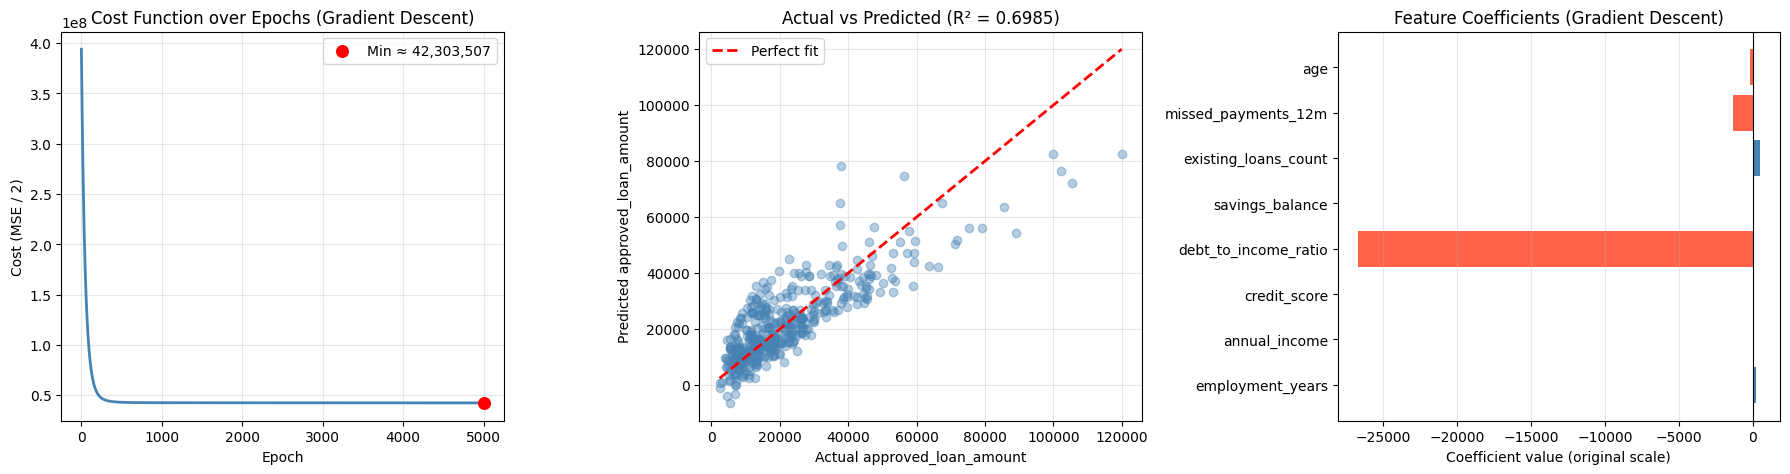

In [27]:
# Multiple Linear Regression trained with Gradient Descent (minimal cost MSE/2)
# y = b + m1*x1 + m2*x2 + ... + mn*xn

target_col = "approved_loan_amount"

# ── Build aligned X and y from existing notebook variables ──
if "numeric_cols" in globals():
    X_multi = numeric_cols.drop(columns=[target_col]).copy()

    if "target" in globals() and target_col in target.columns:
        y_candidate = target[target_col].copy()
        common_idx = X_multi.index.intersection(y_candidate.index)
        X_multi = X_multi.loc[common_idx]
        y_multi = y_candidate.loc[common_idx]
    else:
        y_multi = numeric_cols.loc[X_multi.index, target_col].copy()
else:
    raise NameError("numeric_cols not found. Run data prep cells first.")

# Joint NaN drop to preserve alignment
model_df = pd.concat([X_multi, y_multi.rename(target_col)], axis=1).dropna()
X_multi = model_df.drop(columns=[target_col])
y_multi = model_df[target_col]

feature_names = X_multi.columns.tolist()
X_all = X_multi.values.astype(float)
y_all = y_multi.values.astype(float)

n_samples, n_features = X_all.shape

# ── Normalize features (stable GD) ──
X_mean = X_all.mean(axis=0)
X_std = X_all.std(axis=0)
X_std[X_std == 0] = 1.0
X_norm = (X_all - X_mean) / X_std

# ── Initialize parameters ──
m_vec = np.zeros(n_features, dtype=float)
b_gd_multi = 0.0

learning_rate = 0.01
n_epochs = 5000
tol = 1e-8
patience = 200

cost_history_multi = []
best_cost = np.inf
wait = 0

# ── Gradient Descent loop (minimize J = (1/2n) * Σ(ŷ - y)^2 ) ──
for epoch in range(n_epochs):
    y_pred_gd_multi = X_norm @ m_vec + b_gd_multi
    residuals = y_pred_gd_multi - y_all

    cost = (1 / (2 * n_samples)) * np.sum(residuals ** 2)
    cost_history_multi.append(cost)

    dm = (1 / n_samples) * (X_norm.T @ residuals)
    db = (1 / n_samples) * np.sum(residuals)

    m_vec -= learning_rate * dm
    b_gd_multi -= learning_rate * db

    if best_cost - cost > tol:
        best_cost = cost
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            break

# ── Convert coefficients back to original scale ──
m_original = m_vec / X_std
b_original = b_gd_multi - np.sum(m_vec * X_mean / X_std)

# ── Final predictions & metrics ──
y_pred_final = X_all @ m_original + b_original
ss_res = np.sum((y_all - y_pred_final) ** 2)
ss_tot = np.sum((y_all - y_all.mean()) ** 2)
r2_gd = 1 - ss_res / ss_tot

# Keep sklearn-like model object for downstream notebook cells
multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)  # initialize sklearn internals
multi_model.coef_ = m_original
multi_model.intercept_ = float(b_original)
y_pred_multi = y_pred_final

# ── Print equation ──
print("=" * 70)
print("Multiple Linear Regression trained with Gradient Descent")
print("=" * 70)
print(f"Samples: {n_samples} | Features: {n_features}")
print()
print("Formula: y = b + m1*x1 + m2*x2 + ... + mn*xn\n")
for i, (feat, coef) in enumerate(zip(feature_names, m_original), start=1):
    print(f"  x{i} = {feat:<30}  m{i} = {coef:+.6f}")
print(f"\n  b (intercept) = {b_original:.6f}\n")

terms = " ".join(f"({c:+.4f})*{f}" for f, c in zip(feature_names, m_original))
print("Full equation:")
print(f"  approved_loan_amount = {b_original:.4f} {terms}\n")

print(f"R²: {r2_gd:.4f}")
print(f"Epochs run: {len(cost_history_multi)} (max={n_epochs})")
print(f"Learning rate: {learning_rate}")
print(f"Final cost (MSE/2): {cost_history_multi[-1]:,.4f}")
print(f"Min   cost (MSE/2): {min(cost_history_multi):,.4f} @ epoch {np.argmin(cost_history_multi)}")

# ── Plots ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Cost over epochs
axes[0].plot(cost_history_multi, color="steelblue", linewidth=2)
axes[0].scatter(
    [np.argmin(cost_history_multi)],
    [min(cost_history_multi)],
    color="red",
    zorder=5,
    s=70,
    label=f"Min ≈ {min(cost_history_multi):,.0f}",
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cost (MSE / 2)")
axes[0].set_title("Cost Function over Epochs (Gradient Descent)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2) Actual vs Predicted
axes[1].scatter(y_all, y_pred_final, alpha=0.4, color="steelblue")
lims = [y_all.min(), y_all.max()]
axes[1].plot(lims, lims, "r--", linewidth=2, label="Perfect fit")
axes[1].set_xlabel("Actual approved_loan_amount")
axes[1].set_ylabel("Predicted approved_loan_amount")
axes[1].set_title(f"Actual vs Predicted (R² = {r2_gd:.4f})")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3) Coefficient bar chart
colors = ["tomato" if c < 0 else "steelblue" for c in m_original]
axes[2].barh(feature_names, m_original, color=colors)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_xlabel("Coefficient value (original scale)")
axes[2].set_title("Feature Coefficients (Gradient Descent)")
axes[2].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

results = []

# 1) Simple Linear Regression (scikit-learn)
if all(k in globals() for k in ["simple_model", "x_simple", "y_simple"]):
    y_true = np.asarray(y_simple)
    y_pred = simple_model.predict(x_simple)
    n, p = len(y_true), x_simple.shape[1]

    results.append({
        "model": "simple_model (sklearn)",
        "R2": r2_score(y_true, y_pred),
        "Adj_R2": 1 - (1 - r2_score(y_true, y_pred)) * (n - 1) / (n - p - 1),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    })

# 2) Simple Linear Regression (Gradient Descent)
if all(k in globals() for k in ["m_gd", "b_gd", "x_norm", "y_vals"]):
    y_true = np.asarray(y_vals)
    y_pred = m_gd * x_norm + b_gd
    n, p = len(y_true), 1

    results.append({
        "model": "simple_model (gradient descent)",
        "R2": r2_score(y_true, y_pred),
        "Adj_R2": 1 - (1 - r2_score(y_true, y_pred)) * (n - 1) / (n - p - 1),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    })

# 3) Multiple Linear Regression
if all(k in globals() for k in ["multi_model", "X_multi", "y_multi"]):
    y_true = np.asarray(y_multi)
    y_pred = multi_model.predict(X_multi)
    n, p = len(y_true), X_multi.shape[1]

    results.append({
        "model": "multi_model (sklearn)",
        "R2": r2_score(y_true, y_pred),
        "Adj_R2": 1 - (1 - r2_score(y_true, y_pred)) * (n - 1) / (n - p - 1),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    })

if results:
    perf_df = pd.DataFrame(results).set_index("model").sort_values("R2", ascending=False)
    display(perf_df)
else:
    print("No trained model variables found. Run model training cells first.")

,R2,Adj_R2,MAE,RMSE
model,,,,
multi_model (sklearn),0.698518,0.692935,6882.726815,9198.205429
simple_model (sklearn),0.594194,0.593270,7799.207048,10671.648098
simple_model (gradient descent),0.551095,0.550072,7922.635079,11224.051061


In [30]:
# Clear and simple explanation of the current R² scores

def _metrics(y, y_pred):
    y = np.asarray(y).ravel()
    y_pred = np.asarray(y_pred).ravel()
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mae = np.mean(np.abs(y - y_pred))
    rmse = np.sqrt(np.mean((y - y_pred) ** 2))
    return r2, mae, rmse

r2_simple_now, mae_simple_now, rmse_simple_now = _metrics(y_true, y_pred_simple)
r2_multi_now, mae_multi_now, rmse_multi_now = _metrics(y_true, y_pred_multi)

abs_err_multi = np.abs(np.asarray(y_true) - np.asarray(y_pred_multi))
large_error_rate = (abs_err_multi > 10000).mean()
negative_pred_rate = (np.asarray(y_pred_multi) < 0).mean()

summary = pd.DataFrame(
    {
        "R2": [r2_simple_now, r2_multi_now],
        "MAE": [mae_simple_now, mae_multi_now],
        "RMSE": [rmse_simple_now, rmse_multi_now],
    },
    index=["Simple regression", "Multiple regression"],
)

print(summary.round(3))
print("\nSimple explanation:\n")
print("The R² is not extremely bad, but it is not very high either.")
print(f"- Simple regression explains about {r2_simple_now:.1%} of the variation.")
print(f"- Multiple regression explains about {r2_multi_now:.1%} of the variation.")
print(f"That means about {(1 - r2_multi_now):.1%} is still not explained by the model.\n")

print("Why the R² is still low/moderate:")
print("1. Linear regression is a simple model.")
print("   It tries to fit a straight-line pattern,")
print("   but loan amounts depend on more complex relationships.\n")

print("2. Some important predictors may be missing.")
print("   Real loan decisions may use extra rules or information not in the dataset.\n")

print("3. There are difficult cases and outliers.")
print(f"   About {large_error_rate:.1%} of predictions miss by more than $10,000.")
print("   Large errors like that push R² down.\n")

print("4. Some predictions are unrealistic.")
print(f"   About {negative_pred_rate:.1%} of the multiple-model predictions are negative.")
print("   That is a sign that the model is too simple for this task.\n")

print("How to improve it:")
print("1. Add better features.")
print("2. Try non-linear models such as Random Forest, XGBoost, or Gradient Boosting.")
print("3. Handle outliers and skewed values.")
print("4. Use feature engineering, such as log transforms or interaction terms.")
print("5. Validate with train/test split and cross-validation.\n")

print("In short:")
print("The R² is limited because predicting loan amount is more complex than a straight-line model can capture.")

                        R2       MAE       RMSE
Simple regression    0.594  7799.207  10671.648
Multiple regression  0.699  6882.727   9198.205

Simple explanation:

The R² is not extremely bad, but it is not very high either.
- Simple regression explains about 59.4% of the variation.
- Multiple regression explains about 69.9% of the variation.
That means about 30.1% is still not explained by the model.

Why the R² is still low/moderate:
1. Linear regression is a simple model.
   It tries to fit a straight-line pattern,
   but loan amounts depend on more complex relationships.

2. Some important predictors may be missing.
   Real loan decisions may use extra rules or information not in the dataset.

3. There are difficult cases and outliers.
   About 23.4% of predictions miss by more than $10,000.
   Large errors like that push R² down.

4. Some predictions are unrealistic.
   About 0.9% of the multiple-model predictions are negative.
   That is a sign that the model is too simple for 

In [31]:
print("When people say the model is 'too simple', they mean it cannot capture the real pattern in the data.")
print()
print("In your notebook, linear regression assumes a mostly straight-line relationship:")
print("    y = m1*x1 + m2*x2 + ... + b")
print()
print("Why that can be too simple for loan prediction:")
print("1. Real loan approvals are often non-linear.")
print("   For example, a small credit score drop may suddenly reduce approval amount a lot.")
print()
print("2. Features may interact with each other.")
print("   Example: high income may help differently depending on debt ratio or missed payments.")
print()
print("3. Linear regression may underfit.")
print("   Underfitting means the model misses important structure in the data.")
print()
print("4. Some predictions become unrealistic, like negative loan amounts.")
print("   That is a sign the model does not match the real decision process well.")
print()
print("For your case:")
print("- simple_model uses only annual_income, so it ignores other important factors.")
print("- multi_model is better, but it still uses a linear formula, which may still be too restrictive.")
print()
print("In short:")
print("A 'too simple' model is one that is easy to understand, but not flexible enough to learn the true relationships in the dataset.")

When people say the model is 'too simple', they mean it cannot capture the real pattern in the data.

In your notebook, linear regression assumes a mostly straight-line relationship:
    y = m1*x1 + m2*x2 + ... + b

Why that can be too simple for loan prediction:
1. Real loan approvals are often non-linear.
   For example, a small credit score drop may suddenly reduce approval amount a lot.

2. Features may interact with each other.
   Example: high income may help differently depending on debt ratio or missed payments.

3. Linear regression may underfit.
   Underfitting means the model misses important structure in the data.

4. Some predictions become unrealistic, like negative loan amounts.
   That is a sign the model does not match the real decision process well.

For your case:
- simple_model uses only annual_income, so it ignores other important factors.
- multi_model is better, but it still uses a linear formula, which may still be too restrictive.

In short:
A 'too simple' mode

In [ ]:
ENd

NameError: name 'ENd' is not defined

In [ ]:
# # 	from matplotlib.pylab import gradient


# R2	Adj_R2	MAE	RMSE
# # model				
# # multi_model (sklearn)	0.698518	0.692935	6882.726815	9198.205429
# # simple_model (sklearn)	0.594194	0.593270	7799.207048	10671.648098
# # simple_model (gradient descent)	0.551095	0.550072	7922.635079	11224.051061

#### Current Model Value(when 0 values have been removed)

In [ ]:
# R2	Adj_R2	MAE	RMSE
# model				
# multi_model (sklearn)	0.698518	0.692935	6882.726815	9198.205429
# simple_model (sklearn)	0.594194	0.593270	7799.207048	10671.648098
# simple_model (gradient descent)	0.551095	0.550072	7922.635079	11224.051061

#### Previous Model Value(due to Underfitting / too many 0 values)

In [ ]:
# simple_model (sklearn)	0.599092	0.598691	8372.083148	10847.758712
# simple_model (gradient descent)	0.541979	0.541520	8819.848481	11594.728535
# multi_model (sklearn)	0.429771	0.425168	9050.740550	11910.086060


In [ ]:
# based on the R2 scores, how can the R2 improve and why is the R2 low



In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# # Diagnose why R² is low and test a better strategy (two-stage model)

# if "y_true" not in globals() or "y_vals" not in globals():
#     print("Run the cell that defines y_true and y_vals first.")
# else:
#     y_true_arr = np.asarray(y_true).ravel()
#     y_pred_arr = np.asarray(y_vals).ravel()

#     if len(y_true_arr) != len(y_pred_arr):
#         print(f"Length mismatch: y_true={len(y_true_arr)}, y_vals={len(y_pred_arr)}")
#     else:
#         zero_rate_true = (y_true_arr == 0).mean()
#         zero_rate_pred = (np.isclose(y_pred_arr, 0)).mean()

#         r2_all = r2_score(y_true_arr, y_pred_arr)
#         mae_all = mean_absolute_error(y_true_arr, y_pred_arr)
#         rmse_all = np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))

#         mask_pos = y_true_arr > 0
#         if mask_pos.sum() > 5:
#             r2_pos = r2_score(y_true_arr[mask_pos], y_pred_arr[mask_pos])
#         else:
#             r2_pos = np.nan

#         print("=== R² diagnosis ===")
#         print(f"R² (all rows): {r2_all:.4f}")
#         print(f"MAE: {mae_all:,.2f}")
#         print(f"RMSE: {rmse_all:,.2f}")
#         print(f"Zero rate in y_true: {zero_rate_true:.2%}")
#         print(f"Zero rate in predictions: {zero_rate_pred:.2%}")
#         print(f"R² on approved-only rows (y_true>0): {r2_pos:.4f}")
#         print()

#         print("Why R² is low:")
#         print("1) Target is zero-inflated (many 0 loan amounts), but predictions are mostly non-zero.")
#         print("2) One linear model is trying to learn two processes at once:")
#         print("   - approval decision (0 vs >0)")
#         print("   - approved amount size")
#         print("3) Linear regression underfits nonlinear relationships and interactions.")
#         print()

# # Optional: quick improvement test with a 2-stage model (classification + regression)
# if all(v in globals() for v in ["numeric_cols", "target"]):

#     X = numeric_cols.drop(columns=["approved_loan_amount"])
#     y = target["approved_loan_amount"].values
#     y_bin = (y > 0).astype(int)

#     X_train, X_test, y_train, y_test, yb_train, yb_test = train_test_split(
#         X, y, y_bin, test_size=0.2, random_state=42
#     )

#     # Stage 1: approve or not
#     clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
#     clf.fit(X_train, yb_train)
#     yb_pred = clf.predict(X_test)

#     # Stage 2: amount for approved cases only
#     reg = RandomForestRegressor(n_estimators=400, random_state=42)
#     reg.fit(X_train[yb_train == 1], y_train[yb_train == 1])

#     y_amt_pred = reg.predict(X_test)
#     y_final_pred = np.where(yb_pred == 1, y_amt_pred, 0.0)

#     print("=== Two-stage model check ===")
#     print(f"R² (test): {r2_score(y_test, y_final_pred):.4f}")
#     print(f"MAE (test): {mean_absolute_error(y_test, y_final_pred):,.2f}")
#     print(f"RMSE (test): {np.sqrt(mean_squared_error(y_test, y_final_pred)):,.2f}")
# else:
#     print("numeric_cols/target not found. Run dataset preparation cells first.")

exporting the non numeric dataframe for another model training

In [ ]:

%store numeric_cols
%store target
%store non_numeric_cols

Stored 'numeric_cols' (DataFrame)
Stored 'target' (DataFrame)
Stored 'non_numeric_cols' (DataFrame)


In [ ]:
end

NameError: name 'end' is not defined

In [ ]:
end

NameError: name 'end' is not defined